<a href="https://colab.research.google.com/github/edwardsajaaa/Machine_Learning_Materi-2025/blob/BIOMEDIS-SINYAL/BIOMEDIS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

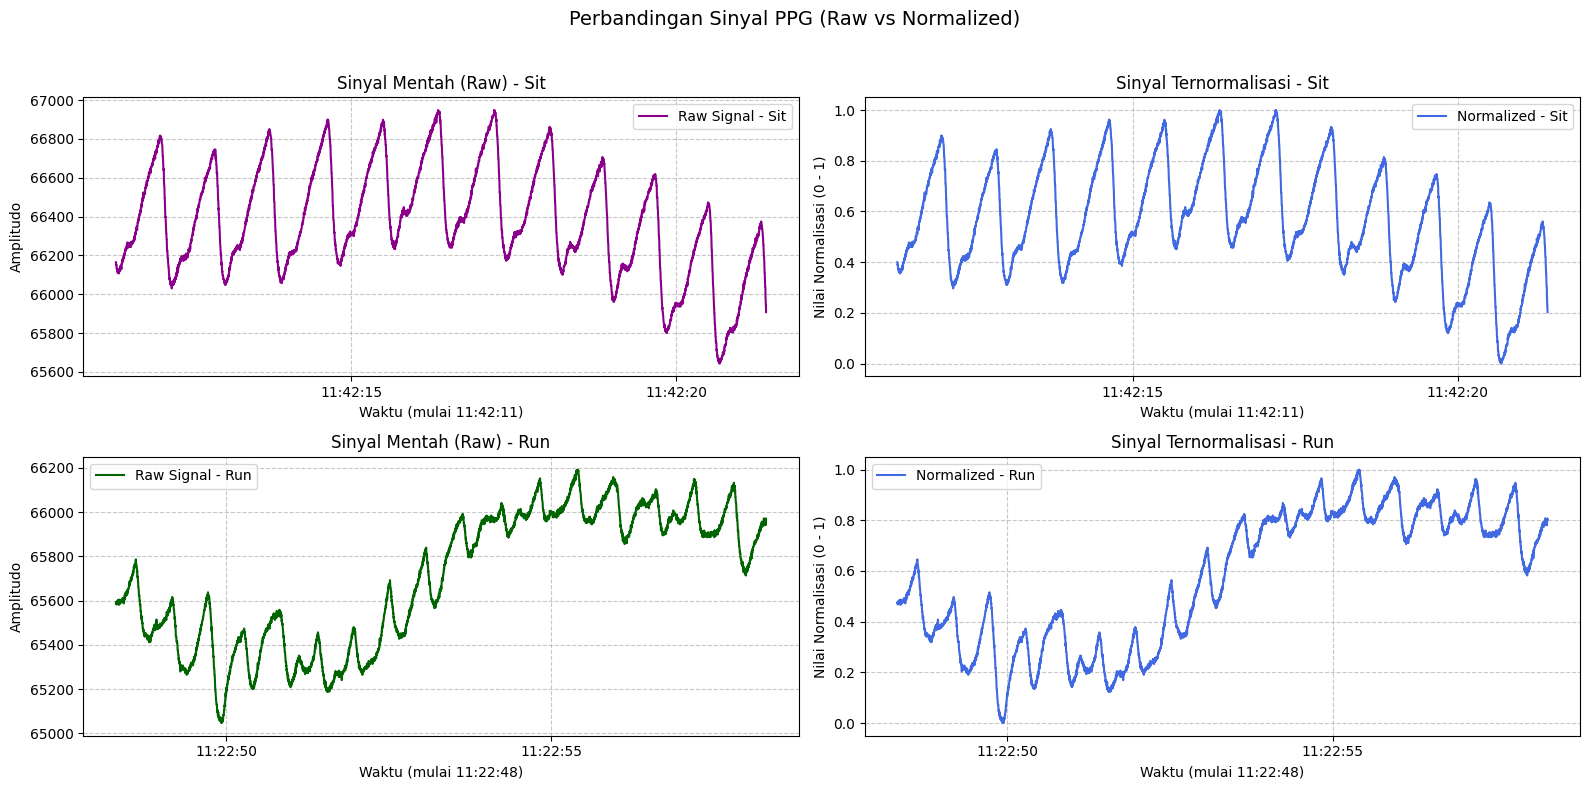

In [ ]:
# ==============================================
# Analisis dan Visualisasi Sinyal PPG (Sit vs Run)
# Dengan Normalisasi Amplitudo
# ==============================================

import pandas as pd
import matplotlib.pyplot as plt

# ----------------------------------------------
# Konfigurasi dasar
# ----------------------------------------------
files = {
    "Sit": "s10_sit.csv",
    "Run": "s10_run.csv"
}

KOLOM_WAKTU = 'time'
KOLOM_PPG = 'pleth_1'
DURASI_PLOT_DETIK = 10


# ----------------------------------------------
# Fungsi untuk memuat dan memangkas data
# ----------------------------------------------
def load_and_trim(file_name, durasi_detik=10):
    """
    Membaca data PPG dari file CSV,
    mengonversi waktu ke format datetime,
    serta memangkas data agar hanya menampilkan
    durasi tertentu (misalnya 10 detik pertama).
    """
    data = pd.read_csv(file_name)

    # Konversi waktu (menghindari error format campuran)
    data[KOLOM_WAKTU] = pd.to_datetime(data[KOLOM_WAKTU], format="mixed", errors="coerce")

    # Hilangkan baris kosong pada kolom waktu
    data = data.dropna(subset=[KOLOM_WAKTU]).reset_index(drop=True)

    # Ambil waktu awal dan batas waktu akhir
    waktu_awal = data[KOLOM_WAKTU].iloc[0]
    waktu_akhir = waktu_awal + pd.Timedelta(seconds=durasi_detik)

    # Potong data sesuai durasi
    return data[data[KOLOM_WAKTU] <= waktu_akhir].copy(), waktu_awal


# ----------------------------------------------
# Fungsi Normalisasi
# ----------------------------------------------
def normalize_signal(series):
    """
    Melakukan normalisasi min-max pada sinyal.
    Hasilnya berada di rentang [0, 1].
    """
    return (series - series.min()) / (series.max() - series.min())


# ----------------------------------------------
# Visualisasi
# ----------------------------------------------
fig, axes = plt.subplots(len(files), 2, figsize=(16, 8), sharex=False)
fig.suptitle("Perbandingan Sinyal PPG (Raw vs Normalized)", fontsize=14)

for row, (label, file) in enumerate(files.items()):
    # Load data
    data_plot, waktu_awal = load_and_trim(file, DURASI_PLOT_DETIK)

    # Pastikan kolom PPG ada
    if KOLOM_PPG not in data_plot.columns:
        print(f"Error: Kolom '{KOLOM_PPG}' tidak ditemukan dalam file '{file}'.")
        print(f"Kolom yang tersedia: {list(data_plot.columns)}")
        continue

    # --- Grafik 1: Raw Signal ---
    axes[row, 0].plot(
        data_plot[KOLOM_WAKTU],
        data_plot[KOLOM_PPG],
        label=f"Raw Signal - {label}",
        color='darkmagenta' if label == "Sit" else 'darkgreen'
    )
    axes[row, 0].set_title(f"Sinyal Mentah (Raw) - {label}")
    axes[row, 0].set_xlabel(f"Waktu (mulai {waktu_awal.strftime('%H:%M:%S')})")
    axes[row, 0].set_ylabel("Amplitudo")
    axes[row, 0].legend()
    axes[row, 0].grid(True, linestyle='--', alpha=0.7)

    # --- Grafik 2: Normalized Signal ---
    data_plot['normalized'] = normalize_signal(data_plot[KOLOM_PPG])

    axes[row, 1].plot(
        data_plot[KOLOM_WAKTU],
        data_plot['normalized'],
        label=f"Normalized - {label}",
        color='royalblue'
    )
    axes[row, 1].set_title(f"Sinyal Ternormalisasi - {label}")
    axes[row, 1].set_xlabel(f"Waktu (mulai {waktu_awal.strftime('%H:%M:%S')})")
    axes[row, 1].set_ylabel("Nilai Normalisasi (0 - 1)")
    axes[row, 1].legend()
    axes[row, 1].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()
